In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
orders = pd.read_csv("C:/Users/Asus/Downloads/project-4 data/orders.csv")
op_prior = pd.read_csv("C:/Users/Asus/Downloads/project-4 data/order_products__prior.csv")
products = pd.read_csv("C:/Users/Asus/Downloads/archive (8)/products.csv")
aisles = pd.read_csv("C:/Users/Asus/Downloads/archive (8)/aisles.csv")
depts = pd.read_csv("C:/Users/Asus/Downloads/archive (8)/departments.csv")
rfm = pd.read_csv("C:/Users/Asus/OneDrive/cleaned_rfm_project-4.csv")
print("Orders shape:",    orders.shape)
print("Op_prior shape:",  op_prior.shape)
print("Products shape:",  products.shape)
print("RFM shape:",       rfm.shape)

In [7]:
products_full = (products
    .merge(aisles,   on='aisle_id')
    .merge(depts,    on='department_id')
)
print("Products full columns:", list(products_full.columns))

Products full columns: ['product_id', 'product_name', 'aisle_id', 'department_id', 'aisle', 'department']


In [8]:
product_stats = op_prior.groupby('product_id').agg(
    order_count   = ('order_id',   'count'),
    reorder_count = ('reordered',  'sum')
).reset_index()

product_stats['reorder_rate'] = (
    product_stats['reorder_count'] / product_stats['order_count']
).round(3)

In [9]:
product_stats = product_stats.merge(
    products_full[['product_id', 'product_name', 'aisle', 'department']],
    on='product_id'
)

In [10]:
product_stats.to_csv('product_affinity.csv', index=False)
print("Exported product_affinity.csv — rows:", len(product_stats))

Exported product_affinity.csv — rows: 49677


In [15]:
rfm = pd.read_csv("C:/Users/Asus/OneDrive/文档/cleaned_rfm_project-4.csv")

In [16]:
print(rfm.head())

   user_id  frequency  recency_days  avg_days_between_orders  r_score  \
0   100264          4             0                     9.25        4   
1   100355          4             0                     2.50        4   
2   100647          4             0                    10.50        4   
3    10184          4             0                    11.50        4   
4   102319          4             0                     8.25        4   

   f_score  rf_score  rfm_score customer_segment  
0        1        41        2.5     New Customer  
1        1        41        2.5     New Customer  
2        1        41        2.5     New Customer  
3        1        41        2.5     New Customer  
4        1        41        2.5     New Customer  


C:\Users\Asus\AppData\Local\Temp\ipykernel_1752\2622033609.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


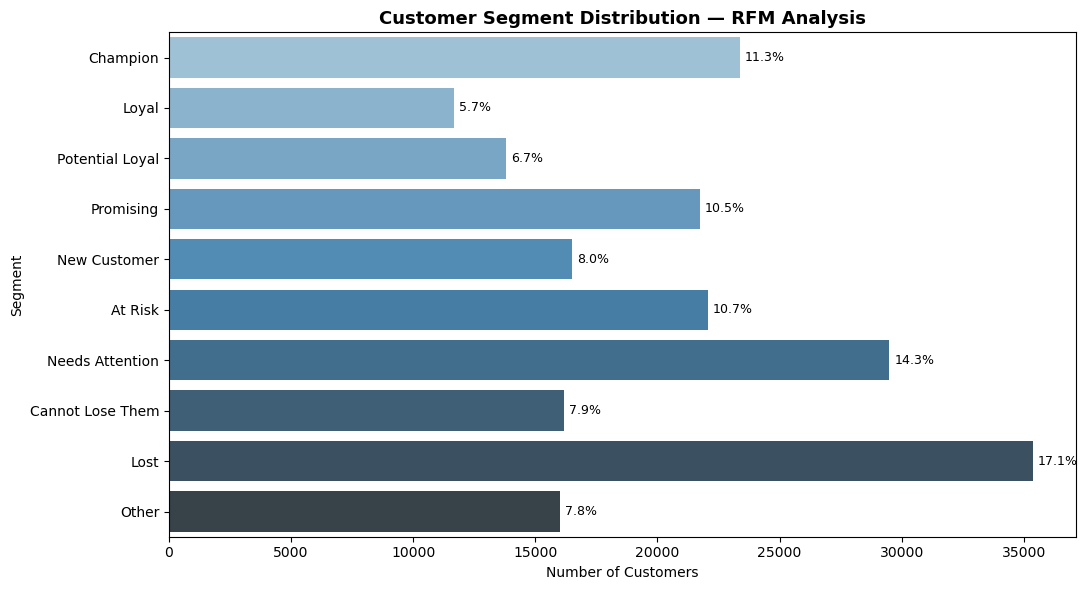

In [17]:
segment_order = [
    'Champion', 'Loyal', 'Potential Loyal', 'Promising',
    'New Customer', 'At Risk', 'Needs Attention',
    'Cannot Lose Them', 'Lost', 'Other'
]
# Filter to only segments that exist in your data
existing = [s for s in segment_order if s in rfm['customer_segment'].values]

seg_counts = rfm['customer_segment'].value_counts().reset_index()
seg_counts.columns = ['customer_segment', 'count']

plt.figure(figsize=(11, 6))
sns.barplot(
    data=seg_counts,
    x='count',
    y='customer_segment',
    order=existing,
    palette='Blues_d'
)
# Add % labels at end of bars
total = len(rfm)
for i, row in enumerate(seg_counts[seg_counts['customer_segment'].isin(existing)]
                         .set_index('customer_segment').loc[existing].itertuples()):
    plt.text(row.count + 200, i, f'{row.count/total*100:.1f}%',
             va='center', fontsize=9)

plt.title('Customer Segment Distribution — RFM Analysis', fontsize=13, fontweight='bold')
plt.xlabel('Number of Customers')
plt.ylabel('Segment')
plt.tight_layout()
plt.savefig('chart1_segment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

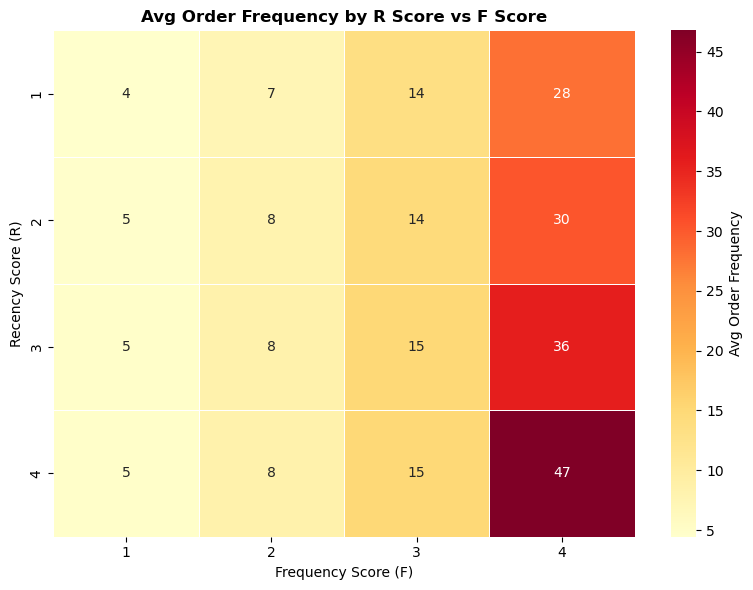

In [18]:
heatmap_data = rfm.groupby(['r_score', 'f_score'])['frequency'].mean().unstack()

plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Avg Order Frequency'}
)
plt.title('Avg Order Frequency by R Score vs F Score', fontsize=12, fontweight='bold')
plt.xlabel('Frequency Score (F)')
plt.ylabel('Recency Score (R)')
plt.tight_layout()
plt.savefig('chart2_rfm_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


C:\Users\Asus\AppData\Local\Temp\ipykernel_1752\805754368.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


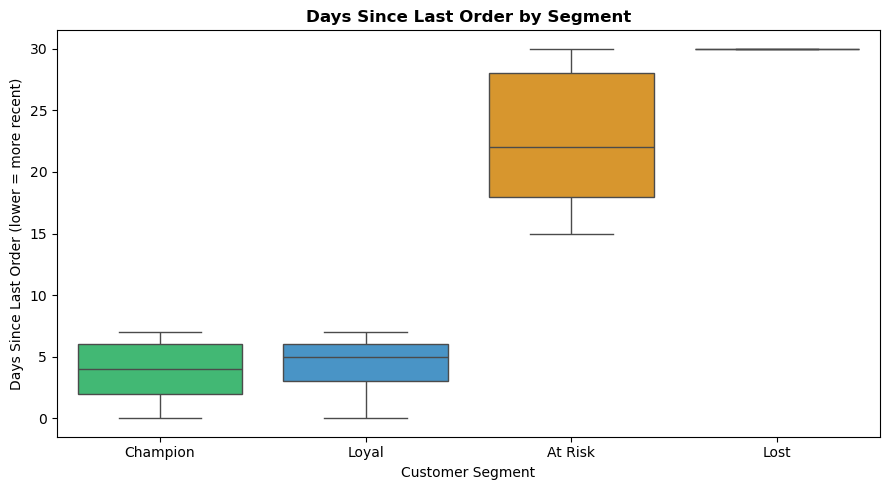

In [19]:
segments_to_compare = ['Champion', 'Loyal', 'At Risk', 'Lost']
rfm_filtered = rfm[rfm['customer_segment'].isin(segments_to_compare)]

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=rfm_filtered,
    x='customer_segment',
    y='recency_days',
    order=segments_to_compare,
    palette={
        'Champion':  '#2ecc71',
        'Loyal':     '#3498db',
        'At Risk':   '#f39c12',
        'Lost':      '#e74c3c'
    }
)
plt.title('Days Since Last Order by Segment', fontsize=12, fontweight='bold')
plt.xlabel('Customer Segment')
plt.ylabel('Days Since Last Order (lower = more recent)')
plt.tight_layout()
plt.savefig('chart3_recency_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_1752\2103669879.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dept_orders, x='OrderCount', y='Department', palette='viridis')


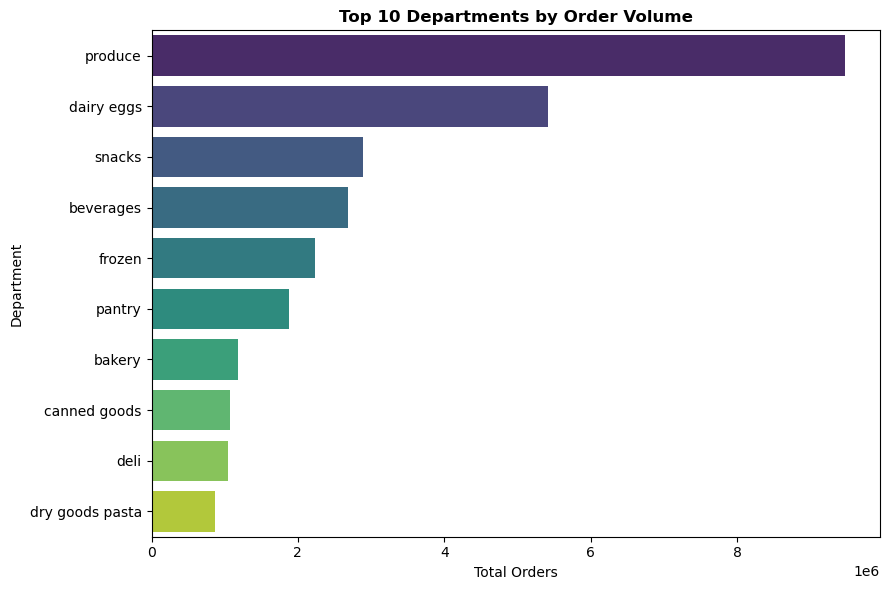

In [20]:
dept_orders = (product_stats
    .groupby('department')['order_count']
    .sum()
    .nlargest(10)
    .reset_index()
)
dept_orders.columns = ['Department', 'OrderCount']

plt.figure(figsize=(9, 6))
sns.barplot(data=dept_orders, x='OrderCount', y='Department', palette='viridis')
plt.title('Top 10 Departments by Order Volume', fontsize=12, fontweight='bold')
plt.xlabel('Total Orders')
plt.tight_layout()
plt.savefig('chart4_top_departments.png', dpi=150, bbox_inches='tight')
plt.show()

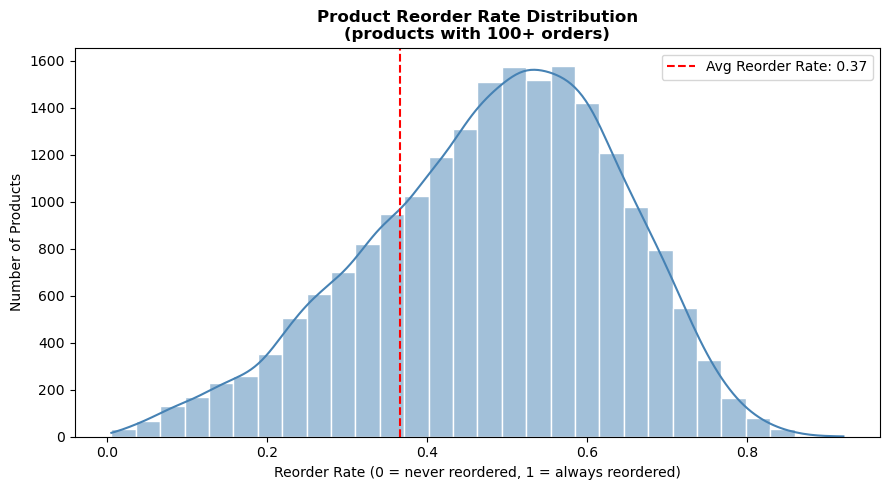

In [21]:
plt.figure(figsize=(9, 5))
sns.histplot(
    product_stats[product_stats['order_count'] >= 100]['reorder_rate'],
    bins=30, kde=True, color='steelblue', edgecolor='white'
)
plt.axvline(
    x=product_stats['reorder_rate'].mean(),
    color='red', linestyle='--',
    label=f"Avg Reorder Rate: {product_stats['reorder_rate'].mean():.2f}"
)
plt.title('Product Reorder Rate Distribution\n(products with 100+ orders)',
          fontsize=12, fontweight='bold')
plt.xlabel('Reorder Rate (0 = never reordered, 1 = always reordered)')
plt.ylabel('Number of Products')
plt.legend()
plt.tight_layout()
plt.savefig('chart5_reorder_rate.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
print("\n--- KEY NUMBERS ---")
print(f"Total unique customers: {len(rfm):,}")
print(f"\nSegment breakdown:")
print(rfm['customer_segment'].value_counts())
print(f"\nChampion avg orders: {rfm[rfm['customer_segment']=='Champion']['frequency'].mean():.1f}")
print(f"Lost avg orders:     {rfm[rfm['customer_segment']=='Lost']['frequency'].mean():.1f}")
print(f"\nAvg reorder rate: {product_stats['reorder_rate'].mean():.3f}")
print(f"Top department: {dept_orders.iloc[0]['Department']}")


--- KEY NUMBERS ---
Total unique customers: 206,209

Segment breakdown:
customer_segment
Lost                35364
Needs Attention     29495
Champion            23370
At Risk             22057
Promising           21748
New Customer        16498
Cannot Lose Them    16188
Other               16009
Potential Loyal     13795
Loyal               11685
Name: count, dtype: int64

Champion avg orders: 46.8
Lost avg orders:     6.0

Avg reorder rate: 0.366
Top department: produce


In [1]:
import os
print(os.getcwd())

C:\Users\Asus
